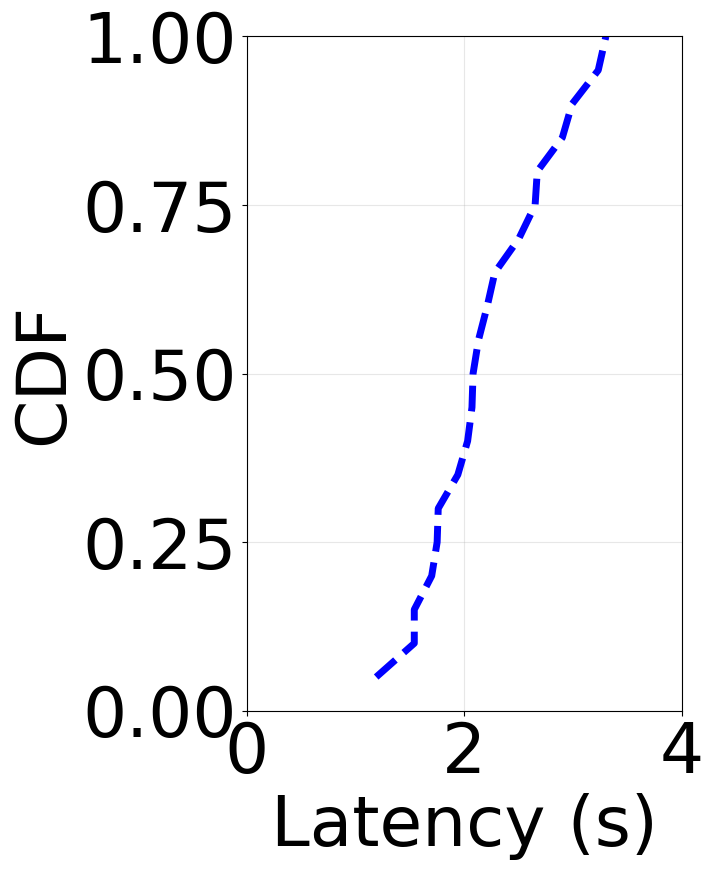

<Figure size 640x480 with 0 Axes>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the Data
# Note: Ensure 'Meta_AI_Latency.xlsm' is in the same directory.
# If the columns in your Excel file are named differently (e.g., "Actual Latency"), 
# please update the column_actual and column_perceived variables below.
file_path = 'Meta_AI_Latency.xlsm'
df = pd.read_excel(file_path)

# standardizing column names if necessary
column_actual = 'Actual Latency'      # Replace with exact column name from Excel if different
column_perceived = 'Perceived Latency' # Replace with exact column name from Excel if different

# 2. Define CDF Calculation Helper
def get_cdf(data):
    """Returns sorted data and the cumulative probability."""
    # Drop NaN values to avoid plotting errors
    data_clean = data.dropna().sort_values()
    # Create an array from 0 to 1
    cdf = np.arange(1, len(data_clean) + 1) / len(data_clean)
    return data_clean, cdf

# 3. Setup Plotting
# Set global font size to 25
plt.rcParams.update({'font.size': 50})

plt.figure(figsize=(8, 10)) # Large figure size to accommodate large font

# 4. Calculate and Plot Actual Latency
x_actual, y_actual = get_cdf(df[column_actual])
# plt.plot(x_actual, y_actual, label='Actual Latency', linewidth=5, color='blue')

# 5. Calculate and Plot Perceived Latency
x_perceived, y_perceived = get_cdf(df[column_perceived])
plt.plot(x_perceived, y_perceived, label='Perceived Latency', linewidth=5, color='blue', linestyle='--')

# 6. Formatting
plt.xlabel('Latency (s)') # Adjust unit if necessary
plt.ylabel('CDF')
# plt.legend(loc='best')
plt.xlim(left=0, right=4)
plt.ylim(bottom=0, top=1)
plt.grid(True, alpha=0.3)

# Ensure no title is displayed
plt.title('') 

plt.tight_layout()
plt.show()
plt.savefig('../Plots/Meta_AI_Latency_CDF.png')